In [1]:
!pip install google-play-scraper
import pandas as pd
import re
import matplotlib.pyplot as plt
from google_play_scraper import reviews
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from collections import Counter
from wordcloud import WordCloud

import nltk
nltk.download('punkt')
nltk.download('stopwords')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.8 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
app_package = "com.whatsapp"

result, _ = reviews(
    app_package,
    lang='en',
    country='in',
    count=2000
)

# Convert to DataFrame
df = pd.DataFrame(result)[['content', 'score', 'at']]
df.columns = ['review', 'rating', 'date']

print("Data collected:", df.shape)
df.head()

Data collected: (2000, 3)


,review,rating,date
0,wast time,5,2026-04-22 15:53:33
1,"So sad,, WhatsApp is not goor for communicatio...",1,2026-04-22 15:53:24
2,good,1,2026-04-22 15:51:59
3,is good,5,2026-04-22 15:51:10
4,Nice,1,2026-04-22 15:49:56


In [3]:
import nltk
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isna(text): # Check for NaN or None values
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # remove special characters
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['clean_review'] = df['review'].apply(clean_text)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [4]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity == 0:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['clean_review'].apply(get_sentiment)

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X = vectorizer.fit_transform(df['clean_review'])

bigrams = vectorizer.get_feature_names_out()
bigram_counts = X.sum(axis=0).A1

bigram_df = pd.DataFrame({'Bigram': bigrams, 'Count': bigram_counts})
bigram_df = bigram_df.sort_values(by='Count', ascending=False)

print("\nTop Bigrams:")
print(bigram_df.head(10))



Top Bigrams:
              Bigram  Count
7           good app     61
4           best app     34
13          nice app     30
10          love app     21
18  whatsapp account     21
8          great app     18
5          dont know     17
2           app ever     16
3           app good     14
12           meta ai     13


In [6]:
low_reviews = df[df['rating'] <= 2]
high_reviews = df[df['rating'] >= 4]

low_words = " ".join(low_reviews['clean_review'])
high_words = " ".join(high_reviews['clean_review'])

low_freq = Counter(low_words.split()).most_common(10)
high_freq = Counter(high_words.split()).most_common(10)

print("\nTop words in LOW ratings:", low_freq)
print("\nTop words in HIGH ratings:", high_freq)



Top words in LOW ratings: [('whatsapp', 136), ('app', 104), ('account', 46), ('please', 43), ('cant', 40), ('good', 39), ('update', 32), ('use', 29), ('number', 26), ('messages', 24)]

Top words in HIGH ratings: [('good', 410), ('app', 328), ('whatsapp', 173), ('nice', 164), ('best', 99), ('love', 66), ('please', 56), ('great', 52), ('excellent', 51), ('like', 48)]


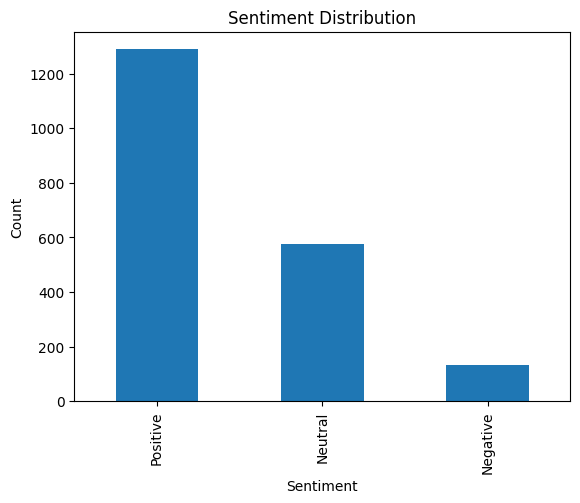

In [7]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


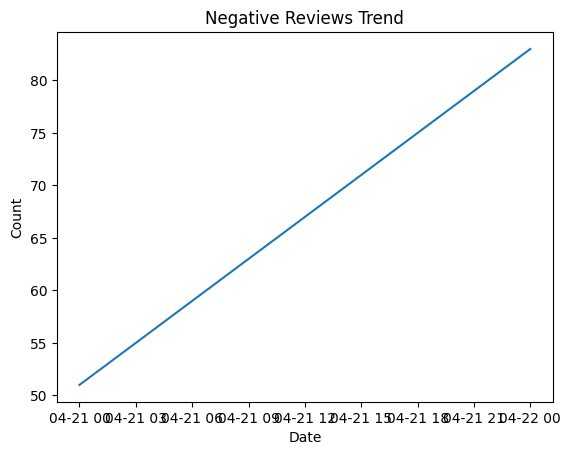

In [8]:
df['date'] = pd.to_datetime(df['date'])
negative_trend = df[df['sentiment'] == "Negative"].groupby(df['date'].dt.date).size()

negative_trend.plot()
plt.title("Negative Reviews Trend")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()

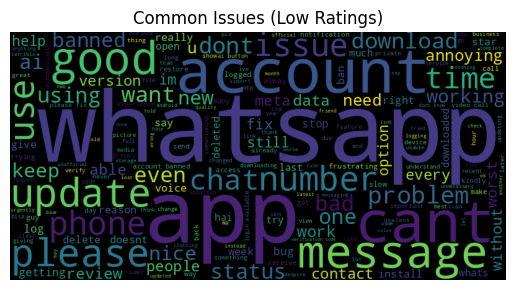

In [9]:
wordcloud = WordCloud(width=800, height=400).generate(low_words)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Common Issues (Low Ratings)")
plt.show()

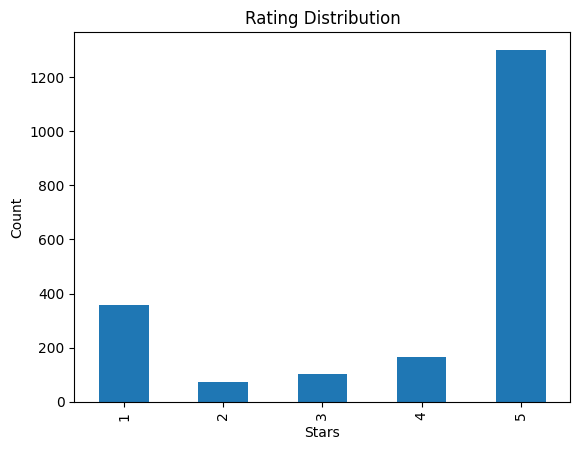

In [10]:
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.show()